In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib

In [67]:
df = pd.read_csv("../dataset/dataset.csv")

In [68]:
df.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,75,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
4,118,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False


In [69]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [70]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
print("Numerical Features:", numerical_features)

categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()
print("Categorical Features:", categorical_features)

Numerical Features: ['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']
Categorical Features: ['International plan', 'Voice mail plan']


In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [73]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [74]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [76]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

In [77]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

MLP Model

In [78]:
input_dim = X_train_processed.shape[1] # cek berapa fitur

In [80]:
from mlp import MLP

model = MLP(input_dim=input_dim) # MLP == ANN

In [81]:
criterion = nn.BCEWithLogitsLoss() # untuk loss nya

In [82]:
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001
) # untuk optimisasi

In [83]:
num_epochs = 50
train_losses = []

In [84]:
for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}]"
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/50]Loss: 0.4218
Epoch [2/50]Loss: 0.2694
Epoch [3/50]Loss: 0.2403
Epoch [4/50]Loss: 0.2261
Epoch [5/50]Loss: 0.2133
Epoch [6/50]Loss: 0.2107
Epoch [7/50]Loss: 0.2074
Epoch [8/50]Loss: 0.2017
Epoch [9/50]Loss: 0.1934
Epoch [10/50]Loss: 0.1977
Epoch [11/50]Loss: 0.1842
Epoch [12/50]Loss: 0.1797
Epoch [13/50]Loss: 0.1905
Epoch [14/50]Loss: 0.1858
Epoch [15/50]Loss: 0.1741
Epoch [16/50]Loss: 0.1808
Epoch [17/50]Loss: 0.1798
Epoch [18/50]Loss: 0.1638
Epoch [19/50]Loss: 0.1653
Epoch [20/50]Loss: 0.1634
Epoch [21/50]Loss: 0.1645
Epoch [22/50]Loss: 0.1513
Epoch [23/50]Loss: 0.1570
Epoch [24/50]Loss: 0.1562
Epoch [25/50]Loss: 0.1662
Epoch [26/50]Loss: 0.1590
Epoch [27/50]Loss: 0.1647
Epoch [28/50]Loss: 0.1617
Epoch [29/50]Loss: 0.1585
Epoch [30/50]Loss: 0.1518
Epoch [31/50]Loss: 0.1520
Epoch [32/50]Loss: 0.1544
Epoch [33/50]Loss: 0.1409
Epoch [34/50]Loss: 0.1398
Epoch [35/50]Loss: 0.1452
Epoch [36/50]Loss: 0.1427
Epoch [37/50]Loss: 0.1365
Epoch [38/50]Loss: 0.1357
Epoch [39/50]Loss: 0.

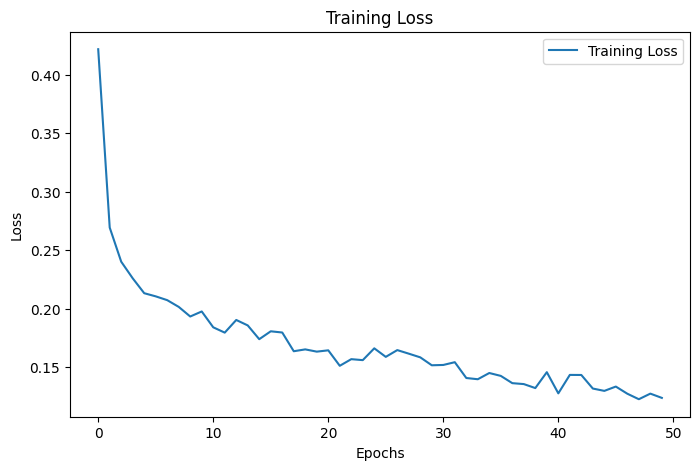

In [85]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

In [86]:
model.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [87]:
with torch.no_grad():

    logits = model(
        X_test_tensor
    )

    probs = torch.sigmoid(
        logits
    )

    y_prob = probs.numpy()

    y_pred = (
        y_prob > 0.5
    ).astype(int)

In [88]:
acc = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_pred
)

In [89]:
print(f"Accuracy : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC : {auc:.4f}")


Accuracy : 0.9625
Precision : 0.8448
Recall : 0.8033
F1 Score : 0.8235
ROC AUC : 0.8926


In [91]:
torch.save(
    model.state_dict(),
    "churn_model.pth"
)

In [92]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [94]:
print(X_train_processed.shape)

(2237, 19)
